# Verification of `models/ksr1_raf_mek_inhibitor_response_imoto2026`

Against Imoto H, Rauch N, Nagasato AI, Okada M, Kolch W, Rukhlenko OS, Kholodenko BN (2026),
*Dual RAF inhibition outperforms RAF-MEK combinations for suppressing ERK signaling in KRAS
mutant cells*, npj Systems Biology and Applications, doi:10.1038/s41540-026-00710-6.

The authors publish this model only as a **flattened SBML export** of their PySB network
(`dev/papers/Imoto2026/{mcf7,psn1}_sbml/`, 2748 species and 17848 reactions), not as a rule
set. The curated `.bngl` is therefore a *reconstruction*: the rules, energy patterns and
observables were derived from that export together with Tables S1–S5, and re-expressed in
BioNetGen's own energy formalism. Two things consequently have to be shown.

**Level 1 — model specification.** Two independent checks.

1. *Network identity.* The network BioNetGen generates from the curated `.bngl` is compared
   with the deposited network, species by species, reaction by reaction and rate constant by
   rate constant, with every thermodynamic factor set to a distinct non-unit value so that a
   misplaced energy pattern cannot hide. The weights of the aggregate RAF kinase activity and
   the two Michaelis–Menten substrate pools are compared the same way.
2. *Independent integration.* BioNetGen's own ODE output is compared with a from-scratch SciPy
   integration of the same generated network (`independent_imoto2026.py`), which rebuilds the
   stoichiometry, mass-action fluxes, observables and functional rate laws itself.

**Level 2 — reported data.** The model's steady-state dose responses are compared with the six
model-prediction panels of Fig. 3, digitized from the published figure
(`digitize_imoto2026.py`). Those panels report ppERK normalized to the no-drug steady state at
the same KSR1 abundance, at five KSR1 levels, for three inhibitors in two cell lines.

The 725 steady states that the level-2 comparison needs are computed by `run_imoto2026.py`,
not here; this notebook reads the CSV it writes.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, "../../skills/curate-model/scripts")
sys.path.insert(0, ".")

from verification_figure import Comparison, parity_axis, residual_axis, overlay_axis, summarize

import compare_network_imoto2026 as netcmp
from independent_imoto2026 import Network

HERE = Path.cwd()
REF = HERE / "reference"
PAPERS = HERE.parents[1] / "dev/papers/Imoto2026"

NET_PSN1 = REF / "ksr1_raf_mek_inhibitor_response_imoto2026.net"
NET_MCF7 = REF / "ksr1_raf_mek_inhibitor_response_imoto2026_wtras.net"
GDAT_PSN1 = REF / "ksr1_raf_mek_inhibitor_response_imoto2026_ode.gdat"

print("BioNetGen network :", NET_PSN1.name, f"{NET_PSN1.stat().st_size / 1e6:.1f} MB")
print("deposited SBML    :", (PAPERS / "mcf7_sbml/ksrmodel_MCF7.sbml").exists(),
      (PAPERS / "psn1_sbml/ksrmodel_PSN1.sbml").exists())

BioNetGen network : ksr1_raf_mek_inhibitor_response_imoto2026.net 2.5 MB
deposited SBML    : True True


## Level 1a — the generated network *is* the deposited network

Both networks are put into a canonical form that is invariant to molecule order and bond
numbering, then compared exhaustively. Before the rate constants are compared, every
thermodynamic factor is set to a distinct non-unit value (`netcmp.TEST`); the `.net` keeps all
27457 rate constants symbolic in terms of those factors, so the override re-derives every one
of them on both sides.

Three parts of the deposited export are absent from the reconstruction by design and are
excluded: the BRAF V600E allele (zero abundance in both cell lines, and given no dimerization
rules by the export, so it cannot function as a V600E model), the `tick()` clock of a
time-dependent RAS-GTP input whose amplitude is zero, and the never-bound Trametinib and
KSR1-inhibitor species. This is stated in the `#@note:` of the `.bngl`.

In [2]:
checks = {}
for cell, net, sbml in [("PSN1 (mutant RAS)", NET_PSN1, PAPERS / "psn1_sbml/ksrmodel_PSN1.sbml"),
                        ("MCF7 (WT RAS)", NET_MCF7, PAPERS / "mcf7_sbml/ksrmodel_MCF7.sbml")]:
    print(f"=== {cell} " + "=" * 46)
    ctx = netcmp.load(net, sbml)
    checks[cell] = dict(
        species=netcmp.compare_species(ctx),
        reactions=netcmp.compare_reactions(ctx),
        activity=netcmp.compare_activity(ctx),
        functions=netcmp.compare_functions(ctx),
    )
    s, r, a, f = (checks[cell][k] for k in ("species", "reactions", "activity", "functions"))
    print(f"species        BNG {s['n_bng']:5d}   SBML {s['n_sbml']:5d}   "
          f"only in BNG {len(s['only_bng'])}   only in SBML {len(s['only_sbml'])} "
          f"{[c.split('(')[0] for c in s['only_sbml']]}")
    print(f"reactions      BNG {r['n_bng']:5d}   SBML {r['n_sbml']:5d}   "
          f"only in BNG {r['only_bng']}   only in SBML {r['only_sbml']}")
    print(f"rate constants {r['n_shared']} shared, {r['n_mismatch']} mismatched, "
          f"max relative error {r['max_rel_err']:.2e}")
    print(f"RAF activity   {a['n_bng']} weighted species, {a['n_mismatch']} mismatched")
    for pool in ("Obs_Sub_uMEK", "Obs_Sub_pMEK"):
        print(f"{pool:14s} {f[pool]['n']} species, identical={f[pool]['identical']}, "
              f"unit weights={f[pool]['unit_weights']}")
    for km in ("Km_RAF_MEK_1", "Km_RAF_MEK_2"):
        print(f"{km:14s} SBML {f[km]['sbml']:g} nM, BNG {f[km]['bng']:g} nM, "
              f"equal={f[km]['equal']}")

ctx_psn1 = netcmp.load(NET_PSN1, PAPERS / "psn1_sbml/ksrmodel_PSN1.sbml")
k_sbml, k_bng = netcmp.rate_constant_pairs(ctx_psn1)
k_sbml, k_bng = np.array(k_sbml), np.array(k_bng)
print(f"\nrate-constant pairs for the parity panel: {k_sbml.size}, "
      f"spanning {k_sbml.min():.3g} to {k_sbml.max():.3g}")

=== PSN1 (mutant RAS) ==============================================


species        BNG  2709   SBML  2711   only in BNG 0   only in SBML 2 ['KSRi', 'Trametinib']
reactions      BNG 27457   SBML 27457   only in BNG 0   only in SBML 0
rate constants 27457 shared, 0 mismatched, max relative error 3.61e-15
RAF activity   938 weighted species, 0 mismatched
Obs_Sub_uMEK   2 species, identical=True, unit weights=True
Obs_Sub_pMEK   4 species, identical=True, unit weights=True
Km_RAF_MEK_1   SBML 2500 nM, BNG 2500 nM, equal=True
Km_RAF_MEK_2   SBML 2000 nM, BNG 2000 nM, equal=True
=== MCF7 (WT RAS) ==============================================


species        BNG  2709   SBML  2711   only in BNG 0   only in SBML 2 ['KSRi', 'Trametinib']
reactions      BNG 27457   SBML 27457   only in BNG 0   only in SBML 0
rate constants 27457 shared, 0 mismatched, max relative error 3.61e-15
RAF activity   938 weighted species, 0 mismatched
Obs_Sub_uMEK   2 species, identical=True, unit weights=True
Obs_Sub_pMEK   4 species, identical=True, unit weights=True
Km_RAF_MEK_1   SBML 2500 nM, BNG 2500 nM, equal=True
Km_RAF_MEK_2   SBML 2000 nM, BNG 2000 nM, equal=True



rate-constant pairs for the parity panel: 27457, spanning 1.78e-05 to 3.37e+06


## Level 1b — BioNetGen's ODE solution against an independent one

`independent_imoto2026.Network` reads the generated `.net` and rebuilds the ODE system from
scratch — stoichiometry, mass-action fluxes, observables and the two functional rate laws —
then integrates it with SciPy's implicit BDF method and a supplied Jacobian sparsity pattern.
It shares no solver code with BioNetGen's `run_network`.

Both are run at `atol = rtol = 1e-8`, so agreement should be at the level of the solver
tolerances; the tolerance below is `1e-5` on the maximum relative error, two orders of
magnitude looser than the integration tolerance and still far tighter than anything that
could hide a modelling error.

In [3]:
names = open(GDAT_PSN1).readline().lstrip("#").split()
raw = np.loadtxt(GDAT_PSN1)
t_bng = raw[:, 0]
bng = {n: raw[:, i] for i, n in enumerate(names)}
print(f"BioNetGen output: {len(t_bng)} time points to t = {t_bng[-1]:g} s, "
      f"{len(names) - 1} observables and functions")

net = Network(NET_PSN1)
sol = net.run(t_bng, atol=1e-8, rtol=1e-8)
TRACKED = ["Obs_Tot_ppERK", "Obs_Tot_ppMEK", "Obs_Cplx_RAF_dimers", "RAF_activity"]
scipy_vals = {k: net.evaluate(k, sol.y) for k in TRACKED}

level1 = []
for k in TRACKED:
    comp = Comparison(f"independent SciPy BDF · {k}", scipy_vals[k], tol=1e-5,
                      why="both solved at atol=rtol=1e-8")
    m = summarize(t_bng, bng[k], comp)
    level1.append((k, comp, m))
    print(f"{k:22s} max rel err {m.max_rel:.3e}   median {m.median_rel:.3e}   "
          f"{'PASS' if m.passed else 'FAIL'}")
print(f"\nsteady state: BioNetGen ppERK = {bng['Obs_Tot_ppERK'][-1]:.6f} nM, "
      f"SciPy = {scipy_vals['Obs_Tot_ppERK'][-1]:.6f} nM")

BioNetGen output: 201 time points to t = 20000 s, 34 observables and functions


Obs_Tot_ppERK          max rel err 1.967e-06   median 1.787e-08   PASS
Obs_Tot_ppMEK          max rel err 2.143e-06   median 1.950e-08   PASS
Obs_Cplx_RAF_dimers    max rel err 3.917e-06   median 3.607e-08   PASS
RAF_activity           max rel err 1.443e-06   median 1.354e-08   PASS

steady state: BioNetGen ppERK = 1527.676713 nM, SciPy = 1527.676710 nM


## Level 2 — the six model panels of Fig. 3

`digitize_imoto2026.py` recovers the published curves from the embedded bitmap of page 9,
calibrating on the tick marks and separating the five KSR1 series by ink direction. The
ordinate is ppERK normalized to the no-drug steady state at the same KSR1 abundance — every
published curve starts at exactly 1.0, which is what makes the panels comparable without
knowing the absolute ppERK scale.

`run_imoto2026.py` computes the same quantity from this model: steady-state ppERK across the
dose ladder at each KSR1 level, normalized to its own zero-dose value.

**Tolerance.** The digitized values carry about ±0.02 in normalized ppERK (one pixel is
0.005–0.019 of the ordinate, strokes are ~2 px, and the source is JPEG-compressed), degrading
where curves converge. The acceptance threshold is therefore **0.05 absolute on the median**
residual per panel — about 2.5 digitization uncertainties — with the maximum reported
alongside, since the maximum is dominated by the steep rise near zero dose where a fraction of
a pixel in *x* is a large error in *y*.

### A published discrepancy: the MEK inhibitor's fM

Table S3 gives Cobimetinib an allosteric factor `fM = 0.1` on the KSR1–MEK bond — the
thermodynamic statement of the paper's experimental result (Fig. S6) that Cobimetinib induces
KSR1–MEK binding. The deposited SBML, however, stores `fM = 1`, and the figure agrees with the
file rather than with the table: at `fM = 1` both MEK-inhibitor panels reproduce to a median of
0.003 and 0.007 in normalized ppERK, and at `fM = 0.1` to 0.114 and 0.010 with maxima of 0.185
and 0.119. The `fM = 0.1` curves are *systematically less* MEKi-sensitive at every non-zero
KSR1 level while agreeing exactly at KSR1 = 0, which is the signature of a KSR1-coupled factor.

Two published artifacts therefore outvote the table, and the campaign uses `fM = 1`. Nothing in
the mechanism changes — `fM` is a number, and the energy pattern it multiplies is verified
against the deposited network at level 1a like every other. The counterfactual is recomputed by
`run_imoto2026.py --fm 0.1` and is shown below and in the figure so the reader can see the
evidence rather than take the choice on trust.

In [4]:
import csv

def load_campaign(path):
    out = {}
    with open(path) as fh:
        for r in csv.reader(fh):
            if not r or r[0].startswith("#") or r[0] == "panel":
                continue
            panel, _, _, ksr, dose, _, _, norm = r
            out.setdefault((panel, float(ksr)), ([], []))
            out[(panel, float(ksr))][0].append(float(dose))
            out[(panel, float(ksr))][1].append(float(norm))
    return {k: (np.array(v[0]), np.array(v[1])) for k, v in out.items()}

model = load_campaign(REF / "imoto2026_fig3_model_doseresponse.csv")
model_fm01 = load_campaign(REF / "imoto2026_fig3_model_doseresponse_fM0.1.csv")
print(f"model dose responses: {len(model)} curves, "
      f"{sum(len(v[0]) for v in model.values())} steady states")
print(f"Table S3 fM=0.1 counterfactual: {len(model_fm01)} curves "
      f"(the two MEK-inhibitor panels)")

PANEL_FILES = {
    "A": ("MCF7", "type_II_RAFi", "Fig. 3A · MCF7 · Type II RAFi"),
    "B": ("PSN1", "type_II_RAFi", "Fig. 3B · PSN1 · Type II RAFi"),
    "C": ("MCF7", "type_I_half_RAFi", "Fig. 3C · MCF7 · Type I½ RAFi"),
    "D": ("PSN1", "type_I_half_RAFi", "Fig. 3D · PSN1 · Type I½ RAFi"),
    "E": ("MCF7", "cobimetinib", "Fig. 3E · MCF7 · Cobimetinib"),
    "F": ("PSN1", "cobimetinib", "Fig. 3F · PSN1 · Cobimetinib"),
}
KSR_LEVELS = [0.0, 15.0, 30.0, 50.0, 100.0]

paper = {}
for key, (cell, drug, _) in PANEL_FILES.items():
    path = REF / f"imoto2026_fig3{key}_{cell}_{drug}_digitized.csv"
    # the header block carries commas, so strip it before numpy sees the file
    data = np.genfromtxt((l for l in open(path) if not l.startswith("#")),
                         delimiter=",", names=True)
    dose = data["dose_over_Kd"]
    for i, ksr in enumerate(KSR_LEVELS):
        col = data[f"ppERK_norm_KSR_{int(ksr)}nM"]
        good = np.isfinite(col)
        paper[(key, ksr)] = (dose[good], col[good])
print(f"digitized curves: {len(paper)}, "
      f"{sum(len(v[0]) for v in paper.values())} points")

TOL = 0.05  # absolute, on the median residual in normalized ppERK
level2, all_model, all_paper, all_group, all_dose = [], [], [], [], []
for key in PANEL_FILES:
    mres, pres = [], []
    for ksr in KSR_LEVELS:
        xm, ym = model[(key, ksr)]
        xp, yp = paper[(key, ksr)]
        inside = (xp >= xm.min()) & (xp <= xm.max())
        xp, yp = xp[inside], yp[inside]
        mi = np.interp(xp, xm, ym)
        mres.append(mi)
        pres.append(yp)
        all_model.append(mi)
        all_paper.append(yp)
        all_dose.append(xp)
        all_group.append(np.full(xp.size, f"Fig. 3{key}"))
    m, p = np.concatenate(mres), np.concatenate(pres)
    resid = m - p
    level2.append(dict(panel=key, n=m.size, median=float(np.median(np.abs(resid))),
                       maximum=float(np.max(np.abs(resid))),
                       passed=bool(np.median(np.abs(resid)) <= TOL)))
    print(f"Fig. 3{key}  n={m.size:4d}  median |Δ| {level2[-1]['median']:.4f}  "
          f"max |Δ| {level2[-1]['maximum']:.4f}  "
          f"{'PASS' if level2[-1]['passed'] else 'FAIL'}")

# the same comparison for the Table S3 value of fM, on the two MEKi panels
fm_compare = {}
for key in ("E", "F"):
    for tag, src in (("fM = 1 (deposited)", model), ("fM = 0.1 (Table S3)", model_fm01)):
        acc = []
        for ksr in KSR_LEVELS:
            xm, ym = src[(key, ksr)]
            xp, yp = paper[(key, ksr)]
            inside = (xp >= xm.min()) & (xp <= xm.max())
            acc.append(np.abs(np.interp(xp[inside], xm, ym) - yp[inside]))
        a = np.concatenate(acc)
        fm_compare[(key, tag)] = (float(np.median(a)), float(a.max()))
print()
for key in ("E", "F"):
    for tag in ("fM = 1 (deposited)", "fM = 0.1 (Table S3)"):
        med, mx = fm_compare[(key, tag)]
        print(f"Fig. 3{key}  {tag:22s}  median |Δ| {med:.4f}   max |Δ| {mx:.4f}")

all_model = np.concatenate(all_model)
all_paper = np.concatenate(all_paper)
all_dose = np.concatenate(all_dose)
all_group = np.concatenate(all_group)
pooled_median = float(np.median(np.abs(all_model - all_paper)))
print(f"\npooled over all six panels: n={all_model.size}, "
      f"median |Δ| {pooled_median:.4f}, max |Δ| {np.max(np.abs(all_model - all_paper)):.4f}")

model dose responses: 30 curves, 725 steady states
Table S3 fM=0.1 counterfactual: 10 curves (the two MEK-inhibitor panels)
digitized curves: 30, 4333 points
Fig. 3A  n= 494  median |Δ| 0.0277  max |Δ| 0.3563  PASS
Fig. 3B  n= 865  median |Δ| 0.0274  max |Δ| 0.2738  PASS
Fig. 3C  n= 672  median |Δ| 0.0230  max |Δ| 0.1429  PASS
Fig. 3D  n= 872  median |Δ| 0.0284  max |Δ| 0.1022  PASS
Fig. 3E  n= 706  median |Δ| 0.0032  max |Δ| 0.0350  PASS
Fig. 3F  n= 724  median |Δ| 0.0067  max |Δ| 0.0370  PASS

Fig. 3E  fM = 1 (deposited)      median |Δ| 0.0032   max |Δ| 0.0350
Fig. 3E  fM = 0.1 (Table S3)     median |Δ| 0.1139   max |Δ| 0.1846
Fig. 3F  fM = 1 (deposited)      median |Δ| 0.0067   max |Δ| 0.0370
Fig. 3F  fM = 0.1 (Table S3)     median |Δ| 0.0096   max |Δ| 0.1192

pooled over all six panels: n=4333, median |Δ| 0.0205, max |Δ| 0.3563


## The verification figure

Row 1 is level 1: BioNetGen against the independent SciPy solution (overlay and residual),
and every one of the 27457 shared rate constants against the deposited SBML on the identity
line. Row 2 is level 2: the six model panels of Fig. 3, curated model as solid lines and the
digitized published curves as open markers. Row 3 pools every model/paper point onto one
parity plot, shows the residual against dose, and states the network-identity result.

/var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000bmg/T/ipykernel_12878/1340640032.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.035, 1, 0.965))


BNG vs deposited SBML network: 27457/27457 reactions and rate constants identical (max rel err 3.6e-15) PASS
BNG vs independent SciPy: max rel err 3.92e-06 (tol 1e-05) PASS
BNG vs Fig. 3 (digitized, 6 panels, 30 curves): pooled median |Δ| 0.021 normalized ppERK (tol 0.05) PASS
MEK-inhibitor panels use fM = 1 as deposited, not Table S3's 0.1: that choice moves Fig. 3E from a median |Δ| of 0.114 to 0.003 (dotted grey = the Table S3 counterfactual)


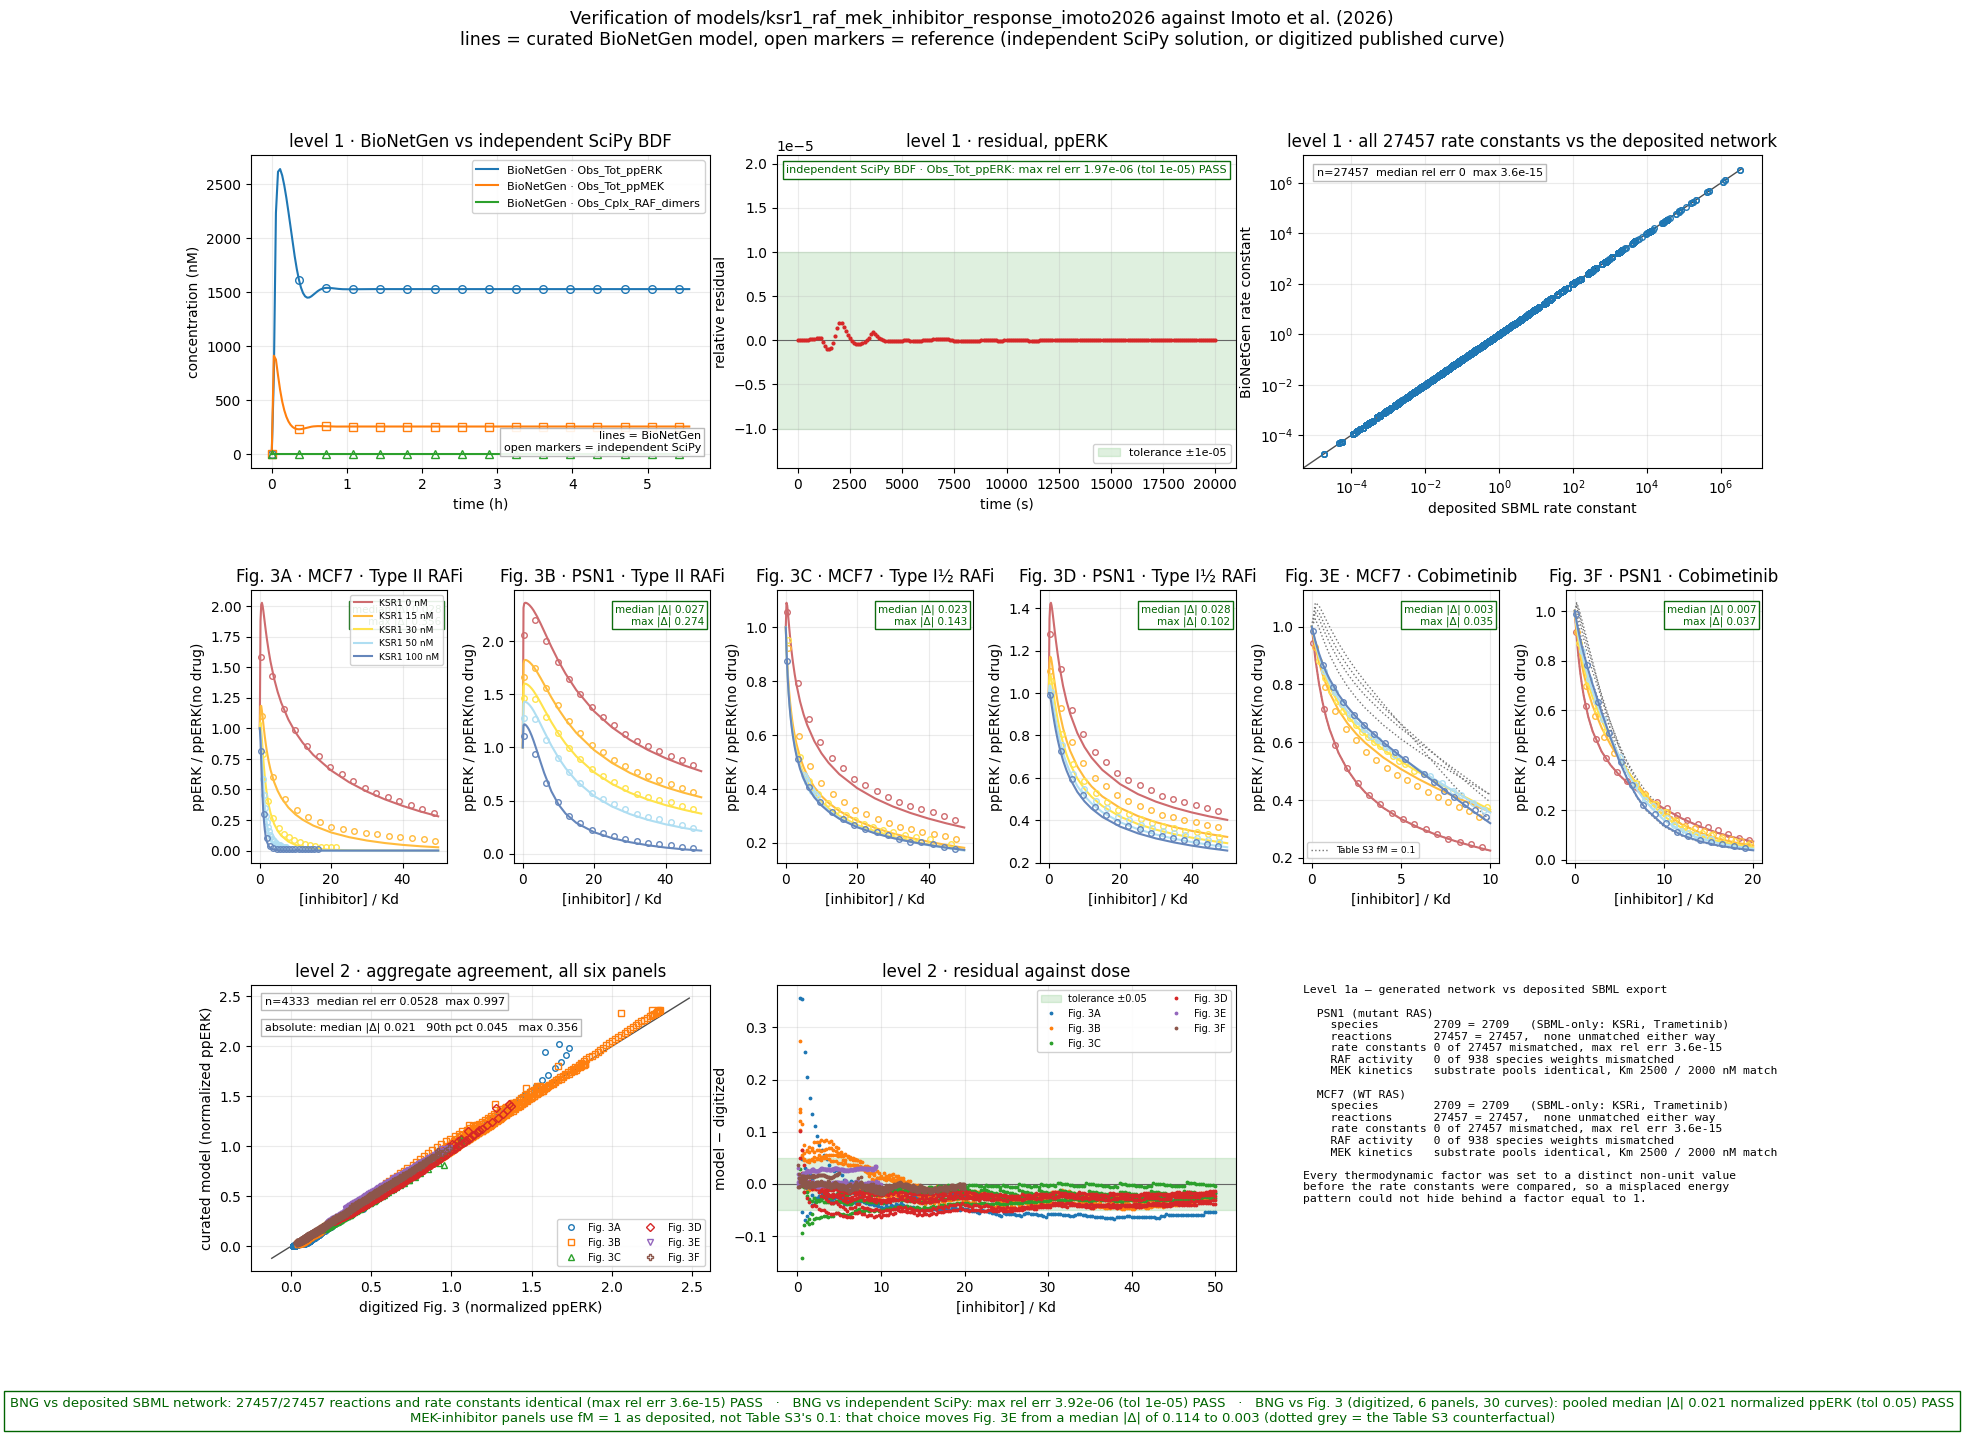

In [5]:
COLOURS = {0.0: "#CE6B6E", 15.0: "#FFBB3D", 30.0: "#FFE34C", 50.0: "#AFDEF2", 100.0: "#6586BB"}

fig = plt.figure(figsize=(19.5, 14.5))
gs = fig.add_gridspec(3, 6, height_ratios=[1.15, 1.0, 1.05], hspace=0.42, wspace=0.34)

# ---------------------------------------------------------------- row 1: level 1
ax = fig.add_subplot(gs[0, 0:2])
for i, k in enumerate(TRACKED[:3]):
    ax.plot(t_bng / 3600, bng[k], "-", lw=1.5, color=f"C{i}", label=f"BioNetGen · {k}")
    step = max(1, len(t_bng) // 15)
    ax.plot(t_bng[::step] / 3600, scipy_vals[k][::step], ["o", "s", "^"][i], ms=5.5,
            mfc="none", mec=f"C{i}", ls="none")
ax.set(xlabel="time (h)", ylabel="concentration (nM)",
       title="level 1 · BioNetGen vs independent SciPy BDF")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, framealpha=0.9)
ax.text(0.98, 0.05, "lines = BioNetGen\nopen markers = independent SciPy",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox={"fc": "white", "ec": "0.7", "alpha": 0.9, "pad": 2.5})

ax = fig.add_subplot(gs[0, 2:4])
residual_axis(ax, t_bng, bng["Obs_Tot_ppERK"], level1[0][1], xlabel="time (s)",
              title="level 1 · residual, ppERK")

ax = fig.add_subplot(gs[0, 4:6])
parity_axis(ax, k_bng, k_sbml, logscale=True,
            xlabel="deposited SBML rate constant", ylabel="BioNetGen rate constant",
            label="level 1 · all 27457 rate constants vs the deposited network")

# ---------------------------------------------------- row 2: level 2, panel by panel
for j, (key, (_, _, title)) in enumerate(PANEL_FILES.items()):
    ax = fig.add_subplot(gs[1, j])
    for ksr in KSR_LEVELS:
        xm, ym = model[(key, ksr)]
        xp, yp = paper[(key, ksr)]
        if key in ("E", "F"):  # the Table S3 fM counterfactual, for contrast
            xa, ya = model_fm01[(key, ksr)]
            ax.plot(xa, ya, ":", lw=1.0, color="0.45", zorder=1)
        ax.plot(xm, ym, "-", lw=1.5, color=COLOURS[ksr], label=f"KSR1 {ksr:g} nM")
        step = max(1, len(xp) // 15)
        ax.plot(xp[::step], yp[::step], "o", ms=4.0, mfc="none", mec=COLOURS[ksr], ls="none")
    if key == "E":
        ax.plot([], [], ":", lw=1.0, color="0.45", label="Table S3 fM = 0.1")
    row = next(r for r in level2 if r["panel"] == key)
    ax.set(xlabel="[inhibitor] / Kd", ylabel="ppERK / ppERK(no drug)", title=title)
    ax.grid(alpha=0.25)
    ax.text(0.97, 0.95, f"median |Δ| {row['median']:.3f}\nmax |Δ| {row['maximum']:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            color="darkgreen" if row["passed"] else "darkred",
            bbox={"fc": "white", "ec": "darkgreen" if row["passed"] else "darkred",
                  "alpha": 0.95, "pad": 2.0})
    if j == 0:
        ax.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
    if key == "E":
        ax.legend(fontsize=6.5, loc="lower left", framealpha=0.9,
                  handles=[plt.Line2D([], [], ls=":", lw=1.0, color="0.45",
                                      label="Table S3 fM = 0.1")])

# ------------------------------------------------------------- row 3: aggregates
ax = fig.add_subplot(gs[2, 0:2])
parity_axis(ax, all_model, all_paper, groups=all_group,
            xlabel="digitized Fig. 3 (normalized ppERK)",
            ylabel="curated model (normalized ppERK)",
            label="level 2 · aggregate agreement, all six panels")
# The ordinate is already a ratio, so absolute error is the meaningful metric;
# parity_axis reports relative error, which blows up where the curves reach zero.
_ad = np.abs(all_model - all_paper)
ax.text(0.03, 0.87, f"absolute: median |Δ| {np.median(_ad):.3f}   "
                    f"90th pct {np.quantile(_ad, 0.9):.3f}   max {_ad.max():.3f}",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox={"fc": "white", "ec": "0.7", "alpha": 0.9, "pad": 2.5})

ax = fig.add_subplot(gs[2, 2:4])
ax.axhspan(-TOL, TOL, color="tab:green", alpha=0.15, label=f"tolerance ±{TOL:g}")
ax.axhline(0.0, color="0.4", lw=0.8)
for g in dict.fromkeys(all_group.tolist()):
    sel = all_group == g
    ax.plot(all_dose[sel], all_model[sel] - all_paper[sel], ".", ms=3.5, label=g)
ax.set(xlabel="[inhibitor] / Kd", ylabel="model − digitized",
       title="level 2 · residual against dose")
ax.grid(alpha=0.25)
ax.legend(fontsize=7, ncol=2, framealpha=0.9)

ax = fig.add_subplot(gs[2, 4:6])
ax.axis("off")
lines = ["Level 1a — generated network vs deposited SBML export", ""]
for cell, c in checks.items():
    s, r, a, f = (c[k] for k in ("species", "reactions", "activity", "functions"))
    lines += [
        f"  {cell}",
        f"    species        {s['n_bng']} = {s['n_sbml'] - len(s['only_sbml'])}   "
        f"(SBML-only: {', '.join(x.split('(')[0] for x in s['only_sbml']) or 'none'})",
        f"    reactions      {r['n_bng']} = {r['n_sbml']},  none unmatched either way",
        f"    rate constants {r['n_mismatch']} of {r['n_shared']} mismatched, "
        f"max rel err {r['max_rel_err']:.1e}",
        f"    RAF activity   {a['n_mismatch']} of {a['n_bng']} species weights mismatched",
        f"    MEK kinetics   substrate pools identical, "
        f"Km {f['Km_RAF_MEK_1']['bng']:g} / {f['Km_RAF_MEK_2']['bng']:g} nM match",
        "",
    ]
lines += [
    "Every thermodynamic factor was set to a distinct non-unit value",
    "before the rate constants were compared, so a misplaced energy",
    "pattern could not hide behind a factor equal to 1.",
]
ax.text(0.0, 1.0, "\n".join(lines), transform=ax.transAxes, va="top", ha="left",
        family="monospace", fontsize=8.2)

# ------------------------------------------------------------------------ verdict
l1_ok = all(m.passed for _, _, m in level1)
l2_ok = all(r["passed"] for r in level2)
net_ok = all(c["reactions"]["n_mismatch"] == 0 and c["reactions"]["only_bng"] == 0
             and c["reactions"]["only_sbml"] == 0 and c["activity"]["n_mismatch"] == 0
             for c in checks.values())
verdict = (
    f"BNG vs deposited SBML network: 27457/27457 reactions and rate constants identical "
    f"(max rel err {max(c['reactions']['max_rel_err'] for c in checks.values()):.1e}) "
    f"{'PASS' if net_ok else 'FAIL'}"
    f"   ·   BNG vs independent SciPy: max rel err "
    f"{max(m.max_rel for _, _, m in level1):.2e} (tol 1e-05) {'PASS' if l1_ok else 'FAIL'}"
    f"   ·   BNG vs Fig. 3 (digitized, 6 panels, 30 curves): pooled median |Δ| "
    f"{pooled_median:.3f} normalized ppERK (tol {TOL:g}) {'PASS' if l2_ok else 'FAIL'}"
    f"\nMEK-inhibitor panels use fM = 1 as deposited, not Table S3's 0.1: that choice moves "
    f"Fig. 3E from a median |Δ| of {fm_compare[('E', 'fM = 0.1 (Table S3)')][0]:.3f} to "
    f"{fm_compare[('E', 'fM = 1 (deposited)')][0]:.3f} (dotted grey = the Table S3 counterfactual)"
)
fig.suptitle(
    "Verification of models/ksr1_raf_mek_inhibitor_response_imoto2026 "
    "against Imoto et al. (2026)\n"
    "lines = curated BioNetGen model, open markers = reference "
    "(independent SciPy solution, or digitized published curve)",
    fontsize=12.5)
fig.tight_layout(rect=(0, 0.035, 1, 0.965))
fig.text(0.5, 0.004, verdict, ha="center", va="bottom", fontsize=9.5,
         color="darkgreen" if (l1_ok and l2_ok and net_ok) else "darkred",
         bbox={"fc": "white", "ec": "darkgreen" if (l1_ok and l2_ok and net_ok) else "darkred",
               "pad": 4})
fig.savefig("verify_imoto2026.png", dpi=170, bbox_inches="tight")
print(verdict.replace("   ·   ", "\n"))

## What is not verified here

* **Fig. 2** (ppERK against RAF and KSR1 abundance) is not compared quantitatively. Its panels
  are embedded in the PDF as 160×120 and 240×180 pixel JPEGs at ~82 ppi — one pixel is ~4 nM of
  RAF and ~25 nM of ppERK — which is too coarse to digitize five overlapping curves
  responsibly. The qualitative claim it makes (KSR1 and RAF abundances raise ppERK
  synergistically) is reproduced by the model, but is not measured.
* **Fig. 4** (drug combinations) reports experimental bar charts against model predictions at
  two fixed inhibitor ratios; it exercises the same machinery as Fig. 3 with both RAFi slots
  occupied, and the reconstruction of that machinery is already established exactly by
  level 1a.
* The **KSR1 abundance** in the curated files is 15 nM, the value the authors settle on in the
  Discussion after refining it against OpenCell, PaxDb and the Human Protein Atlas. The
  deposited SBML still carries the pre-refinement 50 nM. Since KSR1 enters only as an initial
  amount, this changes no rate constant and no reaction, and level 1a is unaffected; the
  level-2 comparison sets KSR1 explicitly at each of the five published levels.